# IMPORT LIBRARIES

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

---
# LOAD DATASET

In [2]:
white_wine_df = pd.read_csv("..\\..\\dataset\\winequality-white.csv", sep=";")

- Dataset: UCI Wine Quality Dataset
- Target variable: quality
- Each row represents chemical properties of wine samples.
---

# DATASET OVERVIEW

In [3]:
print("Shape:", white_wine_df.shape)
white_wine_df.head()

Shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
info_df = pd.DataFrame({
    "Data Type": white_wine_df.dtypes,
    "Non-Null Count": white_wine_df.count(),
    "Missing Values": white_wine_df.isnull().sum()
})

info_df

,Data Type,Non-Null Count,Missing Values
fixed acidity,float64,4898,0
volatile acidity,float64,4898,0
citric acid,float64,4898,0
residual sugar,float64,4898,0
chlorides,float64,4898,0
free sulfur dioxide,float64,4898,0
total sulfur dioxide,float64,4898,0
density,float64,4898,0
pH,float64,4898,0
sulphates,float64,4898,0


In [5]:
white_wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


The dataset contains 4,898 wine samples with 12 variables.  

All features represent physicochemical properties of wine.  

The target variable is **quality**, rated on a scale from 0 to 10.

---

# MISSING VALUES CHECK

In [6]:
white_wine_df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

The dataset does not contain missing values.

Therefore no imputation is required.

---

# TARGET VARIABLE ANALYSIS

<Axes: xlabel='quality', ylabel='count'>

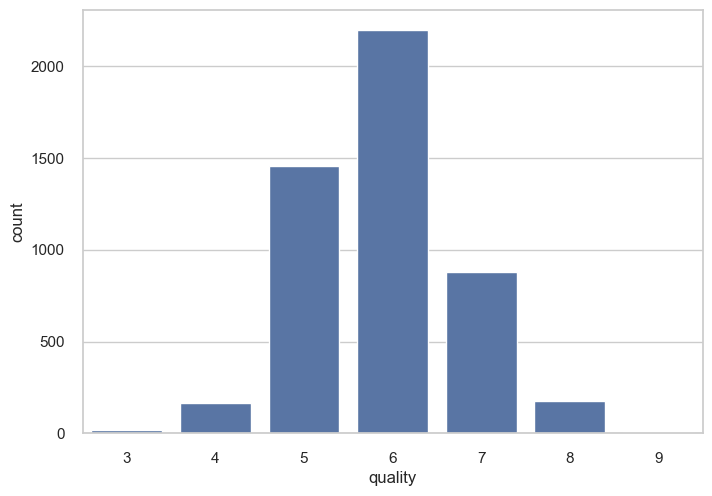

In [7]:
sns.countplot(x="quality", data=white_wine_df)

Wine quality ranges from 3 to 9.

Most samples are concentrated around quality 5 and 6,
showing a slightly imbalanced distribution.

---

# DISTRIBUTION VISUALIZATION

Text(0, 0.5, 'Count')

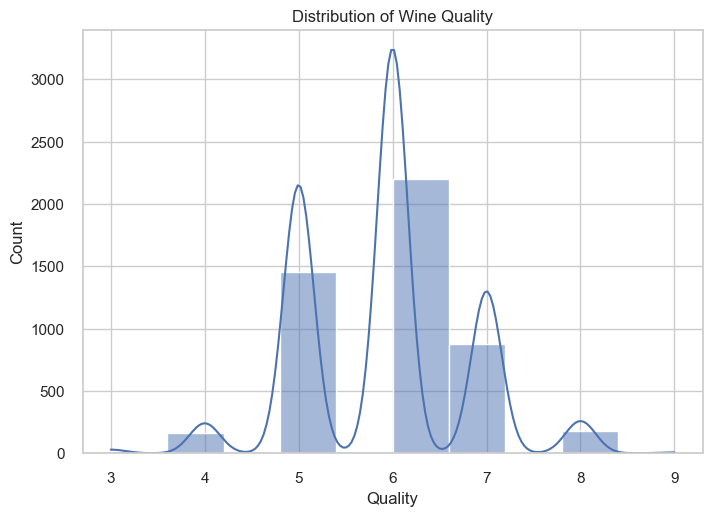

In [8]:
sns.histplot(white_wine_df['quality'], bins=10, kde=True)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")

The histogram shows that most wines fall between quality 5 and 6.

High quality wines (7+) are relatively rare.

---

# CORRELATION ANALYSIS

Correlation strength interpretation:

- 0.00 – 0.19 : Very weak
- 0.20 – 0.39 : Weak
- 0.40 – 0.59 : Moderate
- 0.60 – 0.79 : Strong
- 0.80 – 1.00 : Very strong

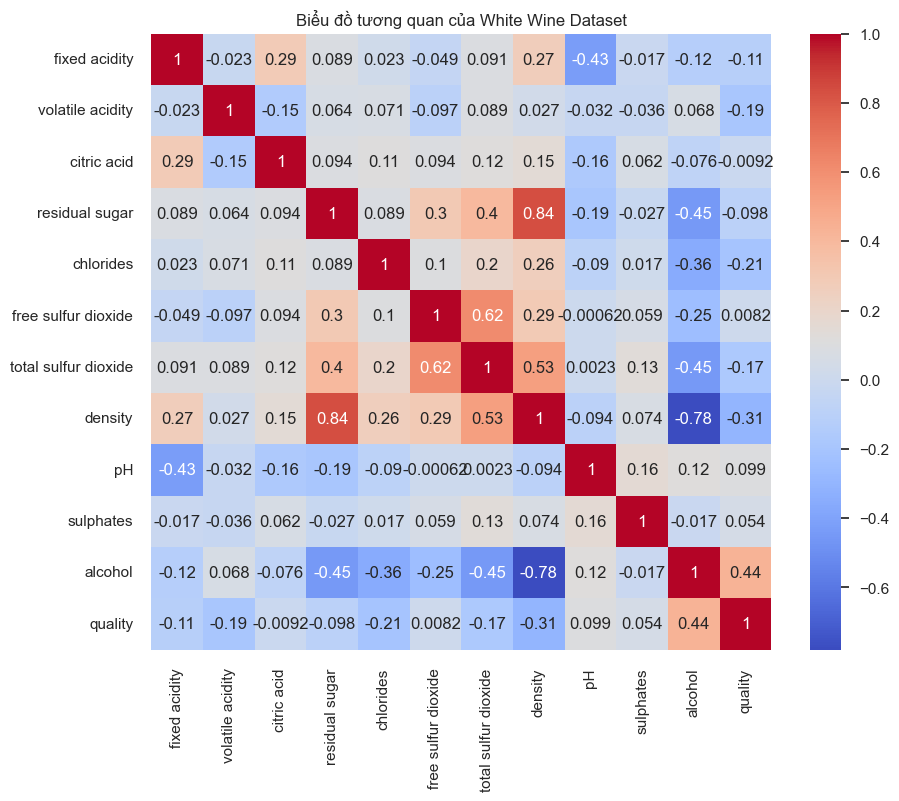

In [9]:
corr_red = white_wine_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_red, annot=True, cmap="coolwarm")
plt.title("Biểu đồ tương quan của White Wine Dataset")
plt.show()

In [10]:
corr_red["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64

The correlation heatmap shows that alcohol has the strongest positive correlation with wine quality, while volatile acidity shows a negative correlation.

Some features such as fixed acidity and citric acid as well as free sulfur dioxide and total sulfur dioxide show relatively strong correlations with each other.

Overall, most features have moderate or weak correlations, indicating that they provide diverse information for predicting wine quality.

In [11]:
upper_red = corr_red.where(np.triu(np.ones(corr_red.shape), k=1).astype(bool))

high_corr_red = upper_red.stack().reset_index()
high_corr_red.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_red = high_corr_red[abs(high_corr_red['Correlation']) >= 0.5]
print(high_corr_red)      

               Feature 1             Feature 2  Correlation
43        residual sugar               density     0.838966
66   free sulfur dioxide  total sulfur dioxide     0.615501
79  total sulfur dioxide               density     0.529881
94               density               alcohol    -0.780138


(|correlation| ≥ 0.5)

Positive correlation: Fixed acidity – citric acid, Fixed acidity – density, Free sulfur dioxide – total sulfur dioxide.

Negative correlation: Fixed acidity – pH, Volatile acidity – citric acid, Citric acid – pH.

---
# OUTLIER ANALYSIS

In [12]:
summary = []

numeric_cols = white_wine_df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    Q1 = white_wine_df[col].quantile(0.25)
    Q3 = white_wine_df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = white_wine_df[(white_wine_df[col] < Q1 - 1.5*IQR) |
                           (white_wine_df[col] > Q3 + 1.5*IQR)]

    num_outliers = len(outliers)
    percentage = num_outliers / len(white_wine_df) * 100

    summary.append([col, num_outliers, percentage])

outlier_df = pd.DataFrame(summary, columns=["Feature", "Outliers", "Percentage (%)"])

outlier_df.index = outlier_df.index + 1

outlier_df

,Feature,Outliers,Percentage (%)
1,fixed acidity,119,2.429563
2,volatile acidity,186,3.797468
3,citric acid,270,5.512454
4,residual sugar,7,0.142915
5,chlorides,208,4.246631
6,free sulfur dioxide,50,1.020825
7,total sulfur dioxide,19,0.387913
8,density,5,0.102082
9,pH,75,1.531237
10,sulphates,124,2.531646


Outliers were detected using the IQR method.

Some features such as residual sugar and chlorides contain a noticeable
percentage of extreme values, which may affect model training.

Further preprocessing may be required depending on the model used.

---

# VISUALIZATION

Text(0.5, 1.0, 'Wine Quality Count')

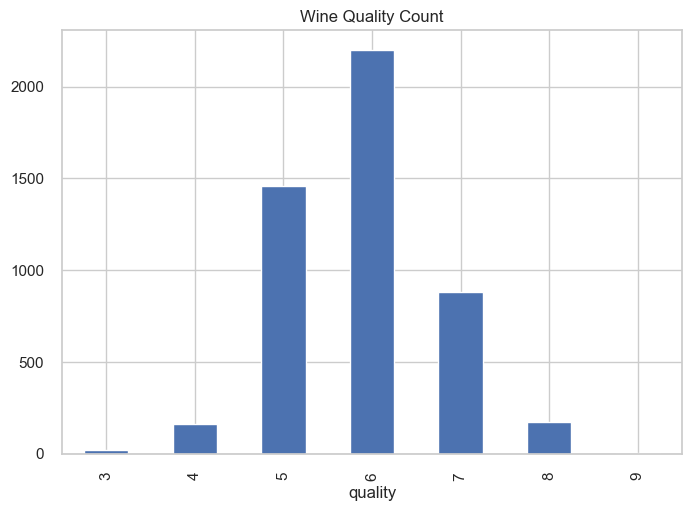

In [13]:
white_wine_df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("Wine Quality Count")

The bar chart confirms that most wine samples are rated **5 or 6**, indicating that the dataset is slightly imbalanced toward medium-quality wines.  
Very low quality (3–4) and high quality (7–8) wines appear much less frequently.

Text(0.5, 1.0, 'Average Alcohol by Quality')

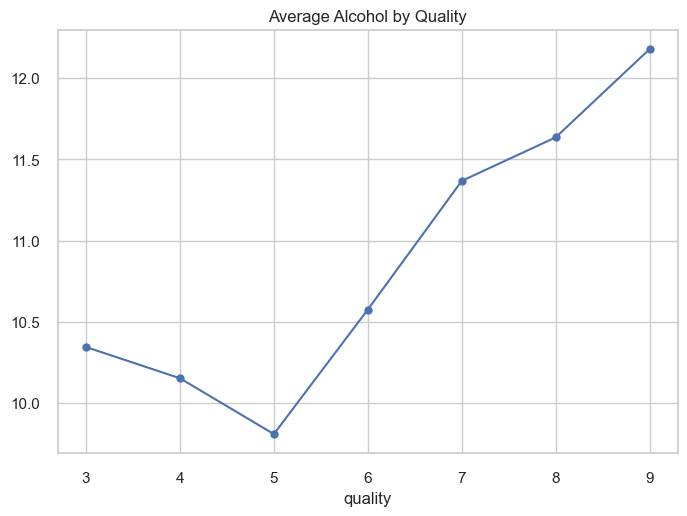

In [14]:
white_wine_df.groupby("quality")["alcohol"].mean().plot(kind='line', marker='o')
plt.title("Average Alcohol by Quality")

The average alcohol content tends to **increase as wine quality increases**.  
This pattern suggests that alcohol may be an important factor influencing wine quality ratings.

<Axes: >

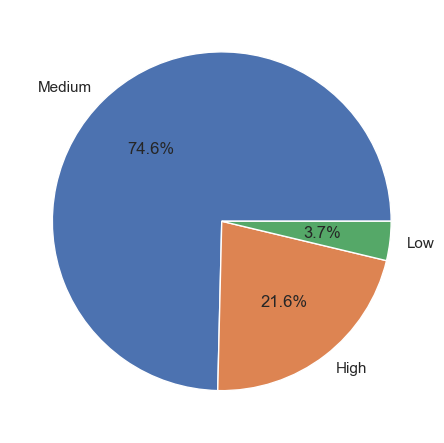

In [15]:
quality_group = pd.cut(white_wine_df['quality'], bins=[0,4,6,10], labels=['Low','Medium','High'])
quality_group.value_counts().plot(kind='pie', autopct='%1.1f%%')

After grouping the quality scores into three categories (Low, Medium, High),  
most wines fall into the **Medium quality group**, while **High-quality wines are relatively rare**.  
This confirms the moderate imbalance observed earlier.

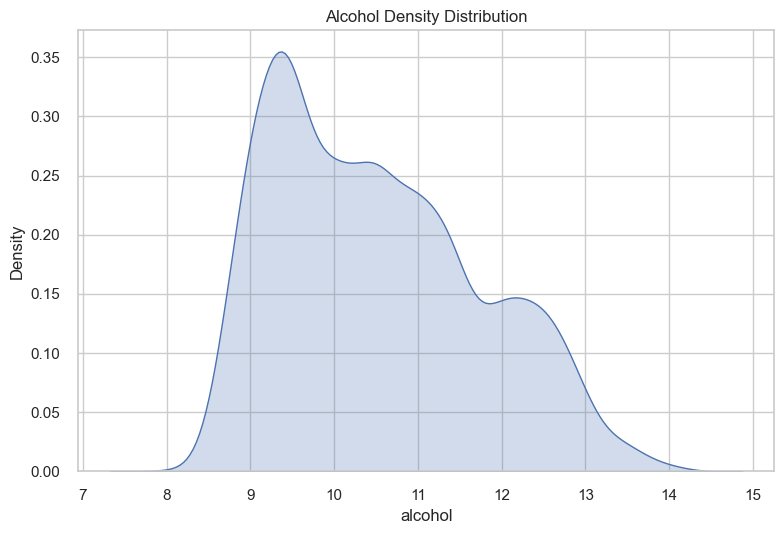

In [16]:
sns.kdeplot(white_wine_df['alcohol'], fill=True)

plt.title("Alcohol Density Distribution")
plt.tight_layout()
plt.show()

The alcohol distribution appears slightly **right-skewed**, with most wines having alcohol content between **9% and 11%**.  
Only a small portion of wines have very high alcohol levels.

---


# FEATURE RELATIONSHIP

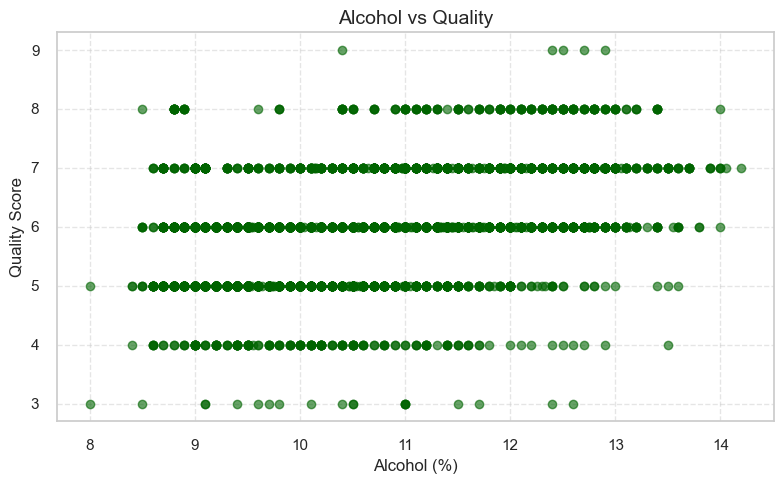

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    white_wine_df['alcohol'], 
    white_wine_df['quality'],
    color='darkgreen',
    alpha=0.6
)

plt.xlabel("Alcohol (%)", fontsize=12)
plt.ylabel("Quality Score", fontsize=12)
plt.title("Alcohol vs Quality", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The scatter plot shows a **positive relationship between alcohol content and wine quality**.  
Although the relationship is not perfectly linear, wines with higher alcohol levels tend to receive higher quality scores.

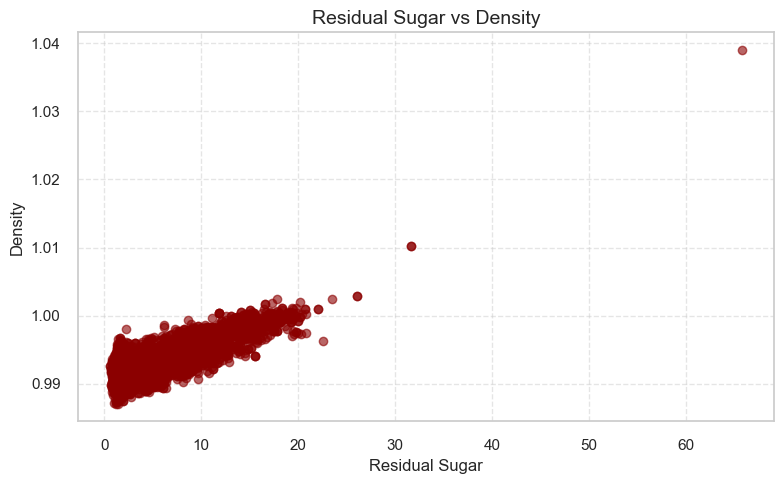

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    white_wine_df['residual sugar'], 
    white_wine_df['density'],
    color='darkred',
    alpha=0.6
)

plt.title("Residual Sugar vs Density", fontsize=14)
plt.xlabel("Residual Sugar", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Residual sugar shows a **positive relationship with wine density**, which is expected since dissolved sugars increase liquid density.  
However, the relationship contains some variability due to the influence of other chemical components.

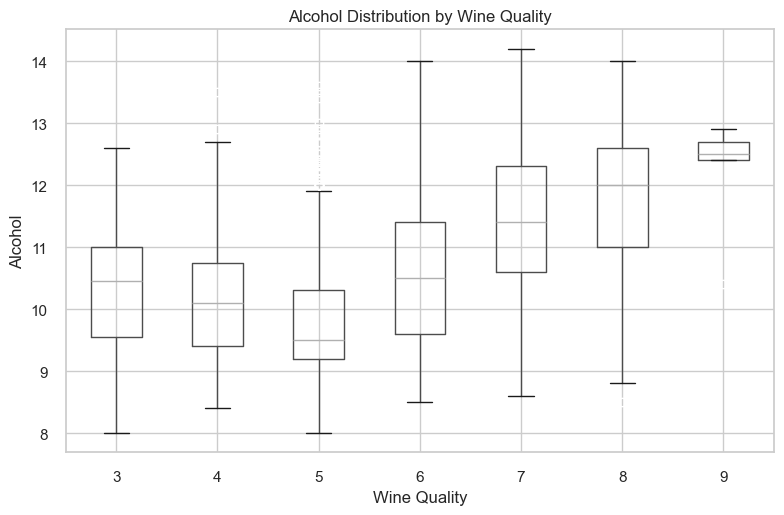

In [19]:
white_wine_df.boxplot(column='alcohol', by='quality')

plt.title("Alcohol Distribution by Wine Quality")
plt.suptitle("")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")
plt.tight_layout()
plt.show()

The boxplot shows that alcohol levels generally increase as wine quality increases.

Higher quality wines tend to have higher median alcohol content.

This suggests a positive relationship between alcohol content and wine quality.

However, some overlap exists between quality levels, indicating that alcohol alone does not fully determine wine quality.

---

# EDA Summary

From the exploratory data analysis, several key insights can be observed:

• The dataset contains **4,898 wine samples with no missing values**, making it suitable for modeling without heavy data cleaning.

• Wine quality scores range from **3 to 9**, with most samples concentrated around **5 and 6**, indicating a moderate class imbalance.

• **Alcohol content shows the strongest positive correlation with wine quality**, suggesting it may be one of the most important predictive features.

• **Volatile acidity tends to negatively correlate with wine quality**, indicating that higher acidity may reduce perceived wine quality.

• Several features contain **outliers**, particularly residual sugar and chlorides, but these may represent valid extreme wine compositions rather than errors.

• Relationships between some variables (such as **residual sugar and density**) reflect expected chemical behavior in wine composition.

Overall, the dataset shows meaningful relationships between physicochemical properties and wine quality, making it suitable for **machine learning models to predict wine quality based on chemical measurements.**